<a href="https://colab.research.google.com/github/Rogerio-mack/sync_nirs/blob/main/Sync_by_coherence_group.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sync Coherence by Group

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Get data

In [2]:
path = 'https://github.com/Rogerio-mack/sync_nirs/raw/refs/heads/main/'

df = pd.read_csv(path + 'fnirs_synthetic_10ch_data.csv')
df_communities_ground_truth = pd.read_csv(path + 'fnirs_synthetic_10ch_groundtruth.csv')

display(df.head())
display(df_communities_ground_truth.head())

,subj,task,time,SD0,SD1,SD2,SD3,SD4,SD5,SD6,SD7,SD8,SD9
0,1,A,0.0,0.173850,1.439444,0.453721,0.090090,1.880227,0.249911,0.535990,-0.450369,-0.041995,-0.275822
1,1,A,0.1,-0.026403,1.541374,0.158524,-0.289698,1.961922,-0.246487,-0.145328,0.798297,-0.379475,1.719652
2,1,A,0.2,0.270659,1.575110,0.282585,-0.075958,1.894357,0.124004,-0.544744,0.764648,-0.493876,-0.623913
3,1,A,0.3,0.598986,1.050629,0.469599,-0.102499,1.882283,0.024815,0.332205,-0.937506,-0.035908,0.963907
4,1,A,0.4,0.005898,1.765079,0.145542,0.413182,1.477168,0.384076,1.069364,-0.846965,0.274944,-0.122699


,subj,task,channel,community
0,1,A,SD7,3
1,1,A,SD8,4
2,1,A,SD9,5
3,1,A,SD0,1
4,1,A,SD1,1


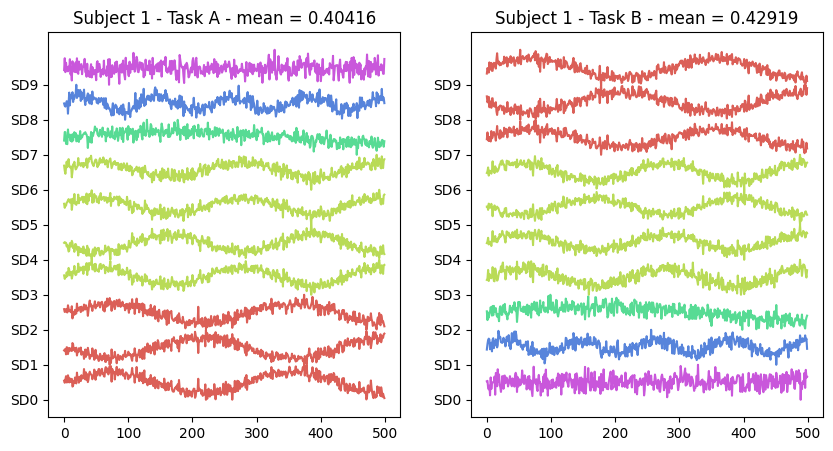

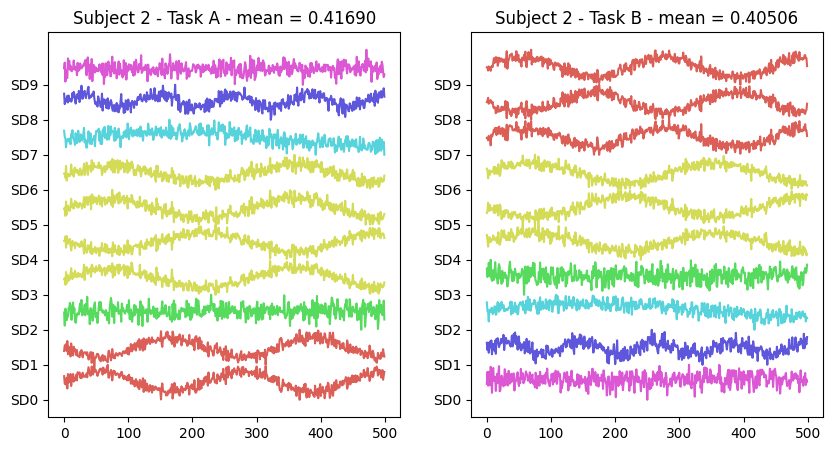

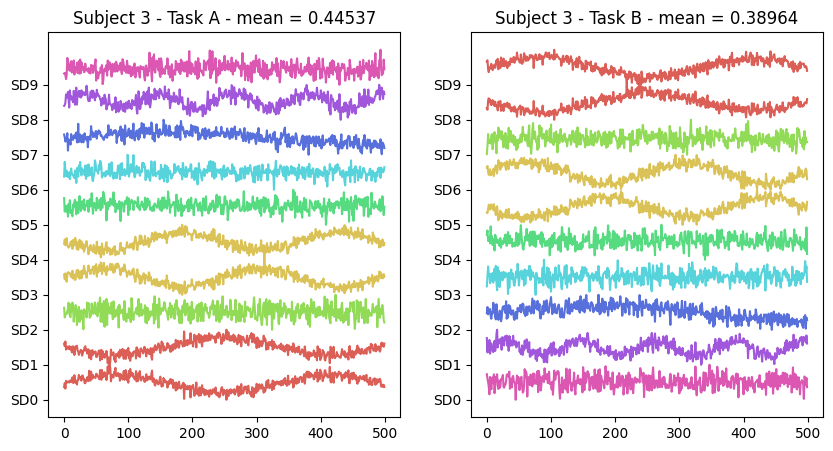

In [3]:
from sklearn.preprocessing import minmax_scale

nr_communities = len(df_communities_ground_truth.community.unique())

cmap = sns.color_palette("hls", nr_communities)

for s in df.subj.unique():
  plt.figure(figsize=(10,5))
  task_nr = 1
  for t in df.task.unique():

    sel_subj_task = (df_communities_ground_truth.subj == s) & (df_communities_ground_truth.task == t)
    df_communities_subj_task = df_communities_ground_truth[sel_subj_task]
    nr_communities = len(df_communities_subj_task.community.unique())
    cmap = sns.color_palette("hls", nr_communities)

    df_temp = df[(df.task == t) & (df.subj == s)]
    df_temp = df_temp.drop(columns=['subj','time','task'])

    for coluna in range(len(df_temp.columns)):
      community_idx = df_communities_subj_task[ df_communities_subj_task.channel == df_temp.columns[coluna] ].community.values[0]
      plt.subplot(1,len(df.task.unique()),task_nr)
      plt.plot(minmax_scale(df_temp.iloc[:,coluna])+coluna, color=cmap[community_idx-1])

      plt.yticks(ticks=range(0,df_temp.shape[1]), labels=df_temp.columns[0:df_temp.shape[1]])
      plt.title(f'Subject {s} - Task {t} - mean = {df_temp.mean().mean():.5f}')
    task_nr = task_nr + 1
  plt.show()


# `compute_coherence_matrix`

In [4]:
!pip install pycwt

In [5]:
!pip install bctpy

In [6]:
from scipy.signal import coherence

def compute_coherence_matrix(signals, fs=10.0):

    n = len(signals)

    matrix = np.zeros((n,n))

    for i in range(n):
        for j in range(i, n): # Compute only upper triangle (including diagonal)
            f, Cxy = coherence(signals[i], signals[j], fs)
            matrix[i,j] = np.mean(Cxy)
            if i != j: # Ensure symmetry by mirroring to the lower triangle
                matrix[j,i] = matrix[i,j]

    adj_matrix = matrix

    return adj_matrix

# Create All Coherence Matrices

In [7]:
import itertools

metodo = compute_coherence_matrix

channel_names = [ col for col in df.columns if col.startswith("S") ]
adj_matrix_set = {}

for  s, t in itertools.product(df.subj.unique(), df.task.unique()):
  signals = np.matrix( df[ (df.subj == s) & (df.task==t) ][ channel_names ] ).T
  adj_matrix_set[(s,t)] = metodo(signals, fs=10.0)

for key, values in adj_matrix_set.items():
  print(key)

(np.int64(1), 'A')
(np.int64(1), 'B')
(np.int64(2), 'A')
(np.int64(2), 'B')
(np.int64(3), 'A')
(np.int64(3), 'B')


In [8]:
adj_matrix_set[(1, 'A')].shape

(10, 10)

# Calc Fisher Average

In [9]:
import numpy as np

def fisher_z_group_average_coherence(group_matrices, eps=1e-5):
    """
    Calcula a média de grupo de matrizes de coerência wavelet (WTC)
    usando a transformação z de Fisher e sua inversa.

    Parâmetros:
    -----------
    group_matrices : np.ndarray
        Array 3D com shape (N_sujeitos, N_canais, N_canais), onde cada matriz
        2D contém valores de coerência WTC no intervalo [0, 1].
    eps : float
        Pequena margem de segurança para evitar divisão por zero / arctanh(1.0) -> inf.

    Retorna:
    --------
    mean_wtc_matrix : np.ndarray
        Matriz 2D (N_canais, N_canais) com a coerência média representativa do grupo.
    """
    matrices = np.asarray(group_matrices, dtype=float)

    # 1. Obter o coeficiente linear r = sqrt(WTC)
    # Clipamos em [0, 1 - eps] para garantir estabilidade numérica no arctanh
    r = np.sqrt(np.clip(matrices, 0.0, 1.0))
    r = np.clip(r, 0.0, 1.0 - eps)

    # 2. Transformação direta de Fisher: z = arctanh(r)
    z_matrices = np.arctanh(r)

    # 3. Média aritmética dos z-scores entre os sujeitos (eixo 0)
    z_mean = np.mean(z_matrices, axis=0)

    # 4. Transformação inversa para retornar à escala de coerência: WTC = (tanh(z_mean))^2
    r_mean = np.tanh(z_mean)
    mean_wtc_matrix = r_mean ** 2

    # 5. Fixar a diagonal principal em 1.0
    np.fill_diagonal(mean_wtc_matrix, 1.0)

    return mean_wtc_matrix

In [10]:
list_subject_adj_matrix = {}

for t in df.task.unique():
  list_subject_adj_matrix[t] = []
  for s in df.subj.unique():
    list_subject_adj_matrix[t].append(adj_matrix_set[(s,t)])


In [11]:
list_subject_adj_matrix.keys()

dict_keys(['A', 'B'])

In [12]:
len(list_subject_adj_matrix['A']), len(list_subject_adj_matrix['B'])

(3, 3)

In [13]:
list_subject_adj_matrix['A'][0].shape

(10, 10)

In [14]:
mean_matrix_by_task = {}

for t in list_subject_adj_matrix.keys():
  # print(f"Task {t}")
  # 1. Empilhar em array 3D: shape (subjs, n_canais, n_canais)
  group_3d_data = np.stack(list_subject_adj_matrix[t], axis=0)
  mean_matrix_by_task[t] = fisher_z_group_average_coherence(group_3d_data)

  # 3. Seguir para o Louvain / Partição de Consenso do grupo
  # W_thresh = bct.threshold_proportional(group_mean_matrix, density=0.25)

In [15]:
mean_matrix_by_task.keys(), mean_matrix_by_task['A'].shape, mean_matrix_by_task['B'].shape

(dict_keys(['A', 'B']), (10, 10), (10, 10))

## Plot matrices

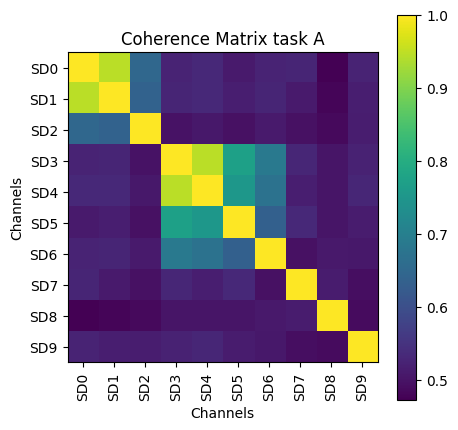

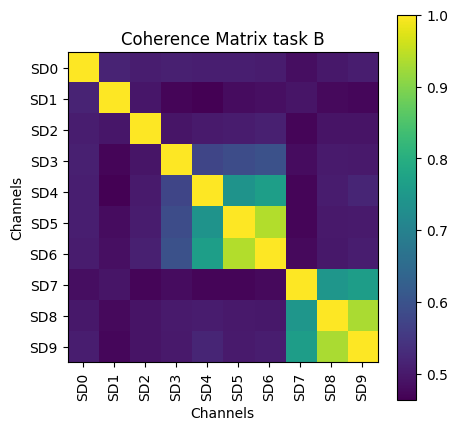

In [16]:
import matplotlib.pyplot as plt

for t in mean_matrix_by_task.keys():

  plt.figure(figsize=(5,5))

  adj_matrix = mean_matrix_by_task[t]

  plt.imshow(adj_matrix, cmap='viridis')
  plt.colorbar()

  plt.title(f'Coherence Matrix task {t}')
  plt.xlabel('Channels')
  plt.ylabel('Channels')
  plt.xticks(range(len(channel_names)), channel_names, rotation=90)
  plt.yticks(range(len(channel_names)), channel_names)

  plt.show()





## `get_communities`

In [17]:
def get_communities(channel_names, adj_matrix, density = 0.25, gamma_louvain = 1.0, all_metrics = True):
  # density = Limiar proporcional mantendo as 25% conexões mais fortes

  def get_metrics(n_null_models=20):

    # Coeficiente de Agrupamento Médio (Clustering Coefficient)
    # Requer normalização dos pesos da matriz para [0, 1]
    W_norm = bct.weight_conversion(W_thresh, 'normalize')
    clustering_coefs = bct.clustering_coef_wu(W_norm)
    C_empirical = np.mean(clustering_coefs)

    # Comprimento Médio do Caminho Característico (Characteristic Path Length - L)
    # Transforma pesos em distâncias inversas (conexão mais forte = menor distância)
    distance_matrix = bct.distance_wei(bct.weight_conversion(W_thresh, 'lengths'))[0]

    # CORREÇÃO PARA LIDAR COM VALORES inf de distance_matrix
    # Encontra o maior valor finito na matriz
    max_val = np.max(distance_matrix [np.isfinite(distance_matrix)])

    # Substitui o 'inf' por esse valor máximo (ou max_val + 1)
    distance_matrix[np.isinf(distance_matrix)] = max_val

    # Ignora distâncias infinitas se houver nós desconexos
    L_empirical = bct.charpath(distance_matrix)[0]

    # -------------------------------------------------------------
    # Small-Worldness (Sigma = (C / C_null) / (L / L_null))
    # -------------------------------------------------------------
    if False:
      C_nulls, L_nulls = [], []
      for _ in range(n_null_models):
          # Gera grafo nulo preservando a distribuição de graus e força dos nós
          W_null, _ = bct.null_model_und_sign(W_thresh)

          # Clustering do grafo nulo
          W_null_norm = bct.weight_conversion(W_null, 'normalize')
          C_nulls.append(np.mean(bct.clustering_coef_wu(W_null_norm)))

          # Path length do grafo nulo
          dist_null = bct.distance_wei(bct.weight_conversion(W_null, 'lengths'))[0]
          L_nulls.append(bct.charpath(dist_null)[0])

      gamma = C_empirical / np.mean(C_nulls)   # Razão de agrupamento
      lambda_ = L_empirical / np.mean(L_nulls) # Razão de caminho
      small_worldness_sigma = gamma / lambda_  # Sigma > 1 indica propriedade small-world

    metrics = {
        'Nodal_Strength': nodal_strength,
        'Nodal_Degree': nodal_degree,
        'Modularity_Q': modularity_Q,
        'Communities': communities,
        'Characteristic_Path_Length_L': L_empirical,
        'Clustering_Coefficient_C': C_empirical,
    #    'Small_Worldness_Sigma': small_worldness_sigma
    }

    return metrics

  # ==========================================
  # 1. Carregar Dados
  # ==========================================
  import bct # Brain Connectivity Toolbox
  from scipy.spatial.distance import squareform
  from scipy.cluster.hierarchy import linkage, leaves_list

  n_channels = len(channel_names)

  # ==========================================
  # 3. Teoria dos Grafos (BCT)
  # ==========================================
  W = adj_matrix.copy()
  np.fill_diagonal(W, 0) # Zera diagonal

  W_thresh = bct.threshold_proportional(W, density, copy=True)
  A_bin = (W_thresh > 0).astype(float)

  # -------------------------------------------------------------
  # Métricas Nodais (Locais)
  # -------------------------------------------------------------
  # Grau (Degree) ou Força Nodal (Strength para matrizes ponderadas)
  nodal_strength = bct.strengths_und(W_thresh)
  nodal_degree = bct.degrees_und(A_bin)

  communities, modularity_Q = bct.community_louvain(W_thresh, gamma=gamma_louvain)

  # Métricas nodais e modulares
  if all_metrics:
    metrics = get_metrics()
  else:
    metrics = {}

  data_communities = pd.DataFrame({'channel': channel_names, 'communities': communities,
                       'nodal_strength': nodal_strength,
                       'nodal_degree': nodal_degree}).sort_values('communities')

  return data_communities, W_thresh, A_bin, modularity_Q, metrics



## density = 0.15, gamma_louvain = 1.0

In [19]:
df_communities_group = {}
W_thresh_group = {}
A_bin_group = {}
modularity_Q_group = {}
metrics_group = {}

channel_names = [ col for col in df.columns if col.startswith("S") ]
metric = 'Coherence'
density = 0.15; gamma_louvain = 1.0

for t in mean_matrix_by_task.keys():
  # data, W_thresh, Q = get_communities(channel_names, adj_matrix, metric)
  adj_matrix = mean_matrix_by_task[t]
  df_communities, W_thresh, A_bin, modularity_Q, metrics = get_communities(channel_names, adj_matrix, density = density, gamma_louvain = gamma_louvain)

  df_communities_group[t] = df_communities
  W_thresh_group[t] = W_thresh
  A_bin_group[t] = A_bin
  modularity_Q_group[t] = modularity_Q
  metrics_group[t] = metrics

  print("\n--- RESULTADOS TOPOLÓGICOS ---")
  print(f"Task: {t}")
  print(f"Modularidade (Q): {modularity_Q_group[t]:.3f}")
  display(df_communities)


--- RESULTADOS TOPOLÓGICOS ---
Task: A
Modularidade (Q): 0.415


,channel,communities,nodal_strength,nodal_degree
0,SD0,1,1.594795,2.0
1,SD1,1,0.945545,1.0
2,SD2,1,0.649249,1.0
3,SD3,2,2.402905,3.0
4,SD4,2,2.366246,3.0
5,SD5,2,1.523940,2.0
6,SD6,2,1.355642,2.0
7,SD7,3,0.000000,0.0
8,SD8,4,0.000000,0.0
9,SD9,5,0.000000,0.0



--- RESULTADOS TOPOLÓGICOS ---
Task: B
Modularidade (Q): 0.494


,channel,communities,nodal_strength,nodal_degree
0,SD0,1,0.000000,0.0
1,SD1,2,0.000000,0.0
2,SD2,3,0.000000,0.0
3,SD3,4,0.597579,1.0
4,SD4,4,1.502062,2.0
5,SD5,4,1.675581,2.0
6,SD6,4,2.298758,3.0
7,SD7,5,1.508484,2.0
8,SD8,5,1.678437,2.0
9,SD9,5,1.694971,2.0


## `get_blocks`

In [20]:
def get_blocks(communities, adj_reordered):

  # communities = data.communities.values
  order = np.argsort(communities)

  sorted_communities_values = communities[order]

  # print("Communities sorted by index (defining blocks):")
  # print(sorted_communities_values)
  # print("\nExtracting blocks from adj_reordered:")

  current_community = -1
  start_idx = 0
  blocks_info = []

  for i, comm_id in enumerate(sorted_communities_values):
      if comm_id != current_community:
          if current_community != -1:
              end_idx = i
              blocks_info.append((current_community, start_idx, end_idx))
          current_community = comm_id
          start_idx = i
      # print(f"Channel {i} belongs to community {comm_id}")
      # print(blocks_info)

  blocks_info.append((current_community, start_idx, len(sorted_communities_values)))

  # for comm_id, start_idx, end_idx in blocks_info:
  #    print(f"\n--- Community Group G{{comm_id}} (Indices {start_idx}:{end_idx}) ---")
  #    block_matrix = adj_reordered[start_idx:end_idx, start_idx:end_idx]
  #    print(block_matrix)

  adj_matrix_blocks = np.ones_like(adj_reordered)

  for comm_id, start_idx, end_idx in blocks_info:
      adj_matrix_blocks[start_idx:end_idx, start_idx:end_idx] = adj_reordered[start_idx:end_idx, start_idx:end_idx]



  return adj_matrix_blocks, blocks_info

# adj_matrix_blocks, blocks_info = get_blocks(data.communities.values, adj_reordered)

# plt.imshow(adj_matrix_blocks, cmap='viridis')
# plt.show()

## `plot_adj_matrix_communities`

In [21]:
def plot_adj_matrix_communities(channel_names, adj_matrix, communities, title):

  # channel_names = [ col for col in df.columns if col.startswith("S") ]
  # metric = 'Coherence'

  if not isinstance(communities, np.ndarray):
    raise ValueError("A variável 'communities' deve ser um np.array()")

  import bct # Brain Connectivity Toolbox

  n_channels = len(channel_names)

  # ==========================================
  # 3. Teoria dos Grafos (BCT)
  # ==========================================
  W = adj_matrix.copy()
  np.fill_diagonal(W, 0) # Zera diagonal

  # Limiar proporcional mantendo as 25% conexões mais fortes
  density = 0.25
  W_thresh = bct.threshold_proportional(W, density, copy=True)

  order = np.argsort(communities)

  # Reordenar todas as matrizes e rótulos
  adj_reordered = adj_matrix[np.ix_(order, order)]
  # p_reordered = p_matrix[np.ix_(order, order)]
  W_thresh_reordered = W_thresh[np.ix_(order, order)]
  # W_sig_reordered = A_bin[np.ix_(order, order)]
  labels_reordered = [channel_names[idx] for idx in order]
  groups = [communities[idx] for idx in order]
  labels_reordered = [f'G{l2}-{l1}' for l1, l2 in zip(labels_reordered, groups)]

  adj_matrix_blocks, blocks_info = get_blocks(communities, adj_reordered)

  # ==========================================
  # 5. Visualização Comparativa
  # ==========================================

  fig, axes = plt.subplots(1, 3, figsize=(12, 4))
  # axes = np.array(axes).flatten()

  # Painel 1: Coerência Reordenada
  im1 = axes[0].imshow(adj_reordered, cmap='viridis', vmin=0, vmax=1)
  # sns.heatmap(adj_reordered, ax=axes[0], cmap='viridis', vmin=0, vmax=1)
  axes[0].set_title(title + f"\nReorder by Communities",fontsize=11,weight='bold')
  axes[0].set_xticks(range(n_channels))
  axes[0].set_xticklabels(labels_reordered, rotation=90, ha='right',fontsize=8)
  axes[0].set_yticks(range(n_channels))
  # axes[0].set_yticklabels(labels_reordered, rotation=0)
  axes[0].set_yticklabels(labels_reordered,fontsize=8)
  fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

  # Matriz Limiarizada com Blocos Modulares
  im2 = axes[1].imshow(W_thresh_reordered, cmap='viridis')
  axes[1].set_title(title + f"\nReorder by Communities ({int(density*100)}% Density)",fontsize=11,weight='bold')
  axes[1].set_xticks(range(n_channels))
  axes[1].set_xticklabels(labels_reordered, rotation=90, ha='right',fontsize=8)
  axes[1].set_yticks(range(n_channels))
  axes[1].set_yticklabels(labels_reordered,fontsize=8)
  fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

  # Matriz Limiarizada com Blocos Modulares
  im3 = axes[2].imshow(adj_matrix_blocks, cmap='viridis')
  axes[2].set_title(title + f"\nCommunities",fontsize=11,weight='bold')
  axes[2].set_xticks(range(n_channels))
  axes[2].set_xticklabels(labels_reordered, rotation=90, ha='right',fontsize=8)
  axes[2].set_yticks(range(n_channels))
  axes[2].set_yticklabels(labels_reordered,fontsize=8)
  fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

  plt.tight_layout()
  plt.show()

  return adj_reordered, W_thresh_reordered, labels_reordered



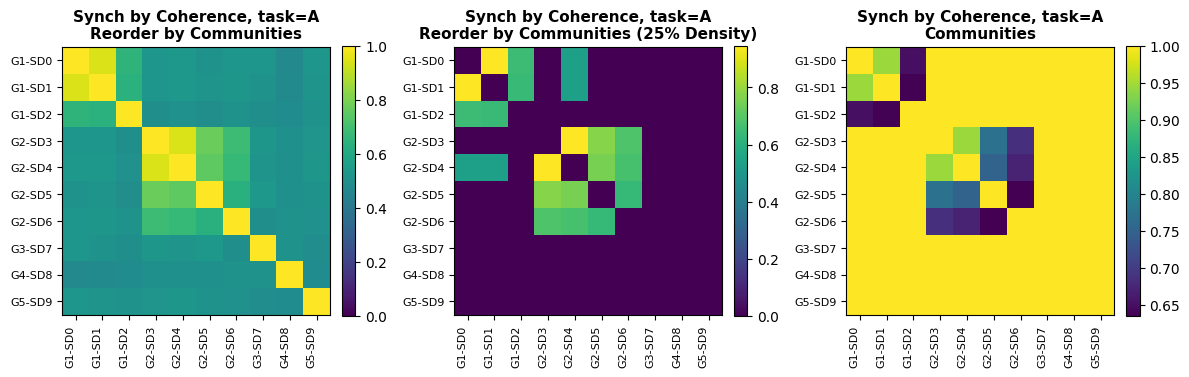

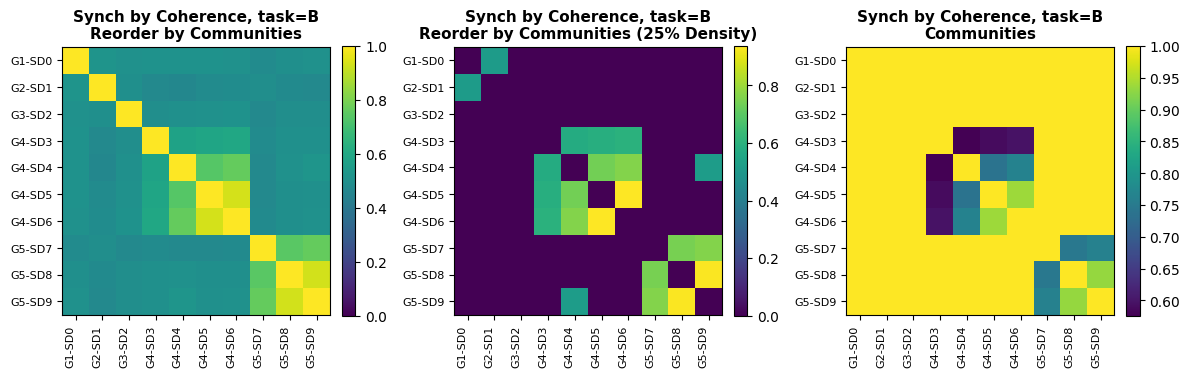

In [22]:
channel_names = [ col for col in df.columns if col.startswith("S") ]

for t in mean_matrix_by_task.keys():
  # data, W_thresh, Q = get_communities(channel_names, adj_matrix, metric)
  adj_matrix = mean_matrix_by_task[t]
  title = f"Synch by {metric}, task={t}"

  adj_reordered, W_thresh_reordered, labels_reordered = plot_adj_matrix_communities(channel_names, adj_matrix, df_communities_group[t].communities.values, title)

## `plot_grafo`

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

def plot_grafo(W, communities, nodal_strength, channel_names, title):
  # 1. Carregar Grafo a partir da matriz limiarizada (W_sig)
  G = nx.from_numpy_array(W)
  mapping = {i: name for i, name in enumerate(channel_names)}
  G = nx.relabel_nodes(G, mapping)

  pos = nx.spring_layout(G, seed=42, k=0.7)

  # 2. Extrair Pesos das Arestas
  edges = G.edges(data=True)
  weights = np.array([d['weight'] for u, v, d in edges])

  # 3. Criar Dicionário com Rótulos Numéricos das Arestas (ex: "0.98")
  edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in edges}

  # 4. Configurar Nós
  max_str = np.max(nodal_strength) if np.max(nodal_strength) > 0 else 1.0
  node_sizes = 600 + 1400 * (nodal_strength / max_str)
  unique_comms = np.unique(communities)
  cmap_nodes = plt.get_cmap('tab10', len(unique_comms))
  node_colors = [cmap_nodes(np.where(unique_comms == comm)[0][0]) for comm in communities]

  plt.figure(figsize=(9, 7))

  # Desenhar Nós e Rótulos dos Canais
  nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, edgecolors='black', linewidths=1.5)
  nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

  # Desenhar Arestas (com espessura e gradiente de cor variando com o peso)
  edge_widths = weights * 4.5
  nx.draw_networkx_edges(
      G, pos,
      width=edge_widths,
      edge_color=weights,
      edge_cmap=plt.cm.Blues,
      edge_vmin=0.0,
      edge_vmax=1.0,
      alpha=0.85
  )

  # Desenhar os Valores Numéricos nas Arestas
  nx.draw_networkx_edge_labels(
      G, pos,
      edge_labels=edge_labels,
      font_size=8,
      font_color='darkblue',
      bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8)
  )

  # Adicionar Barra de Cores (Colorbar) para a Força das Arestas
  sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=plt.Normalize(vmin=0.0, vmax=1.0))
  sm.set_array([])
  cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.046, pad=0.04)
  cbar.set_label('Connection Strengths', rotation=270, labelpad=15)

  # Adicionar legenda de módulos/comunidades
  for comm_id in unique_comms:
      plt.scatter([], [], color=cmap_nodes(np.where(unique_comms == comm_id)[0][0]),
                  label=f'Comm = {comm_id}', s=100, edgecolors='black')

  plt.legend(scatterpoints=1, frameon=True, loc='upper left', title="Communities", fontsize=9)

  plt.title(title, fontsize=12, pad=15, weight='bold')
  plt.axis('off')
  plt.tight_layout()
  plt.show()

  return

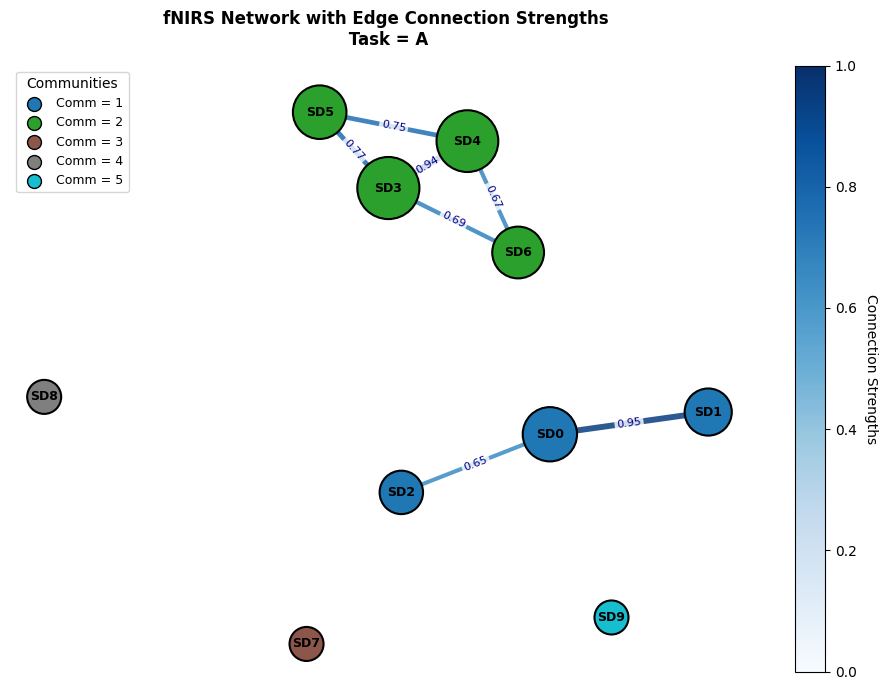

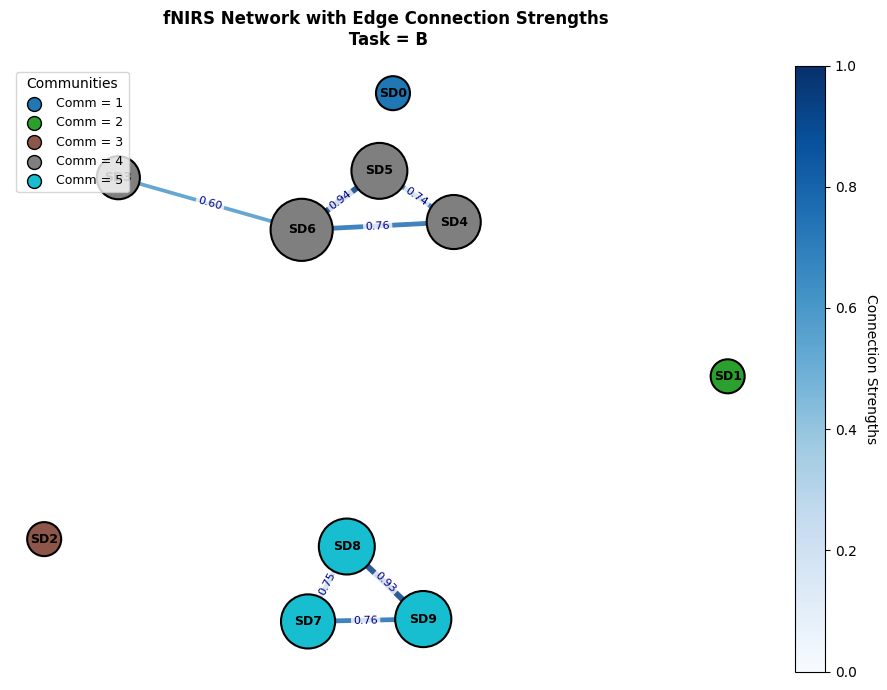

In [24]:
for t in df_communities_group.keys():
  df_communities = df_communities_group[t]

  communities = df_communities.communities.values
  nodal_strength = df_communities.nodal_strength.values
  channel_names = df_communities.channel.values
  W_thresh = W_thresh_group[t]

  title = f"fNIRS Network with Edge Connection Strengths\n Task = {t}"
  plot_grafo(W_thresh, communities, nodal_strength, channel_names, title)